# Exp 6: Polluted Data Clustering

This notebook adds noise and outliers to the Mall Customers dataset, then applies K-Means and Hierarchical clustering on the polluted data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
RANDOM_STATE = 42
NOISE_STD = {
    "Age": 3.0,
    "Annual Income (k$)": 4.0,
    "Spending Score (1-100)": 8.0,
}
OUTLIER_FRACTION = 0.06

base_dir = Path.cwd()
if (base_dir / "Mall_Customers.csv").exists():
    data_path = base_dir / "Mall_Customers.csv"
else:
    data_path = base_dir / "Exp_6" / "Mall_Customers.csv"

df = pd.read_csv(data_path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
def add_noise_and_outliers(df: pd.DataFrame, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    polluted = df.copy()

    for col, std in NOISE_STD.items():
        polluted[col] = polluted[col] + rng.normal(0.0, std, size=len(polluted))

    outlier_count = max(1, int(len(polluted) * OUTLIER_FRACTION))
    outliers = pd.DataFrame({
        "CustomerID": np.arange(polluted["CustomerID"].max() + 1, polluted["CustomerID"].max() + 1 + outlier_count),
        "Gender": rng.choice(["Male", "Female"], size=outlier_count),
        "Age": rng.integers(15, 80, size=outlier_count),
        "Annual Income (k$)": rng.integers(5, 180, size=outlier_count),
        "Spending Score (1-100)": rng.integers(1, 100, size=outlier_count),
    })

    polluted = pd.concat([polluted, outliers], ignore_index=True)
    polluted["Age"] = polluted["Age"].clip(15, 80)
    polluted["Annual Income (k$)"] = polluted["Annual Income (k$)"].clip(5, 180)
    polluted["Spending Score (1-100)"] = polluted["Spending Score (1-100)"].clip(1, 100)

    return polluted

polluted = add_noise_and_outliers(df)
polluted.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19.914151,16.350298,37.563109
1,2,Male,17.880048,20.629927,82.574209
2,3,Female,22.251354,16.362340,12.564228
3,4,Female,25.821694,18.575755,73.850071
4,5,Female,25.146894,8.799312,44.169338


In [4]:
feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = polluted[feature_cols].to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_map = {}
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    silhouette_map[k] = silhouette_score(X_scaled, labels)

best_k = max(silhouette_map, key=silhouette_map.get)
best_k, {k: round(v, 4) for k, v in silhouette_map.items()}

(4,
 {2: 0.3195, 3: 0.3301, 4: 0.3707, 5: 0.3705, 6: 0.3616, 7: 0.3573, 8: 0.3598})

In [5]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
polluted["KMeansCluster"] = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
polluted["HierarchicalCluster"] = hierarchical.fit_predict(X_scaled)

km_score = silhouette_score(X_scaled, polluted["KMeansCluster"])
hc_score = silhouette_score(X_scaled, polluted["HierarchicalCluster"])

print("K-Means silhouette:", round(km_score, 4))
print("Hierarchical silhouette:", round(hc_score, 4))

K-Means silhouette: 0.3707
Hierarchical silhouette: 0.3319


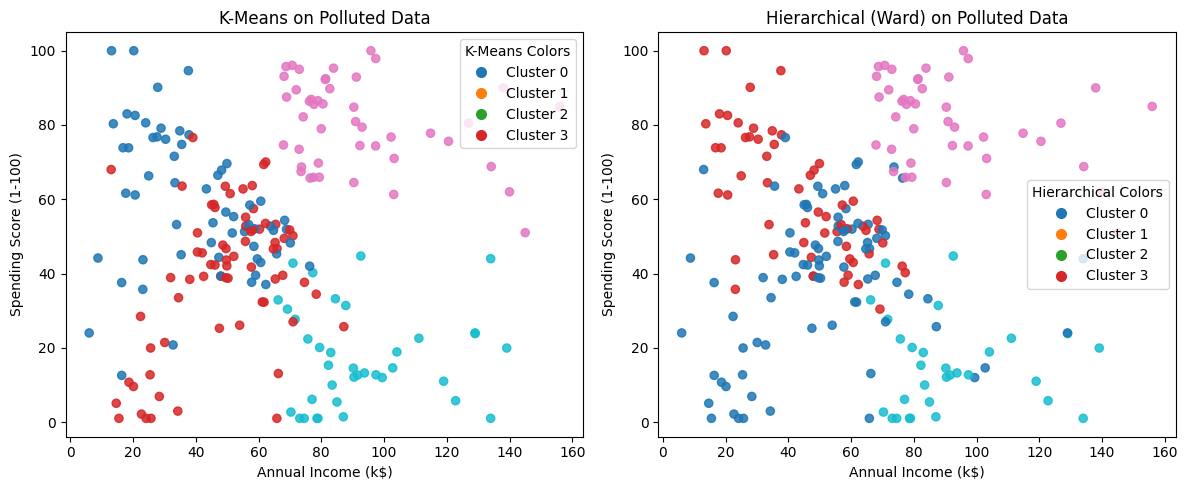

In [6]:
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = plt.get_cmap("tab10")

axes[0].scatter(
    polluted["Annual Income (k$)"],
    polluted["Spending Score (1-100)"],
    c=polluted["KMeansCluster"],
    cmap=cmap,
    s=35,
    alpha=0.85
)
axes[0].set_title("K-Means on Polluted Data")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")

kmeans_labels = sorted(polluted["KMeansCluster"].unique())
kmeans_handles = [
    mlines.Line2D([], [], color=cmap(label % 10), marker="o", linestyle="None",
                  markersize=7, label=f"Cluster {label}")
    for label in kmeans_labels
]
axes[0].legend(handles=kmeans_handles, title="K-Means Colors", loc="best")

axes[1].scatter(
    polluted["Annual Income (k$)"],
    polluted["Spending Score (1-100)"],
    c=polluted["HierarchicalCluster"],
    cmap=cmap,
    s=35,
    alpha=0.85
)
axes[1].set_title("Hierarchical (Ward) on Polluted Data")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")

hier_labels = sorted(polluted["HierarchicalCluster"].unique())
hier_handles = [
    mlines.Line2D([], [], color=cmap(label % 10), marker="o", linestyle="None",
                  markersize=7, label=f"Cluster {label}")
    for label in hier_labels
]
axes[1].legend(handles=hier_handles, title="Hierarchical Colors", loc="best")

plt.tight_layout()
plt.show()

## Color Explanation

- In each plot, every color represents one cluster label shown in the legend (Cluster 0, Cluster 1, etc.).
- Points with the same color in that plot belong to the same cluster.
- Color labels are algorithm-specific, so Cluster 0 in K-Means is not necessarily the same group as Cluster 0 in Hierarchical clustering.
- The legend is the correct reference for interpreting each color.

In [7]:
output_dir = data_path.parent
polluted_csv = output_dir / "Mall_Customers_polluted.csv"
clustered_csv = output_dir / "Mall_Customers_polluted_clustered_from_notebook.csv"

polluted.drop(columns=["KMeansCluster", "HierarchicalCluster"], errors="ignore").to_csv(polluted_csv, index=False)
polluted.to_csv(clustered_csv, index=False)

print("Saved:", polluted_csv)
print("Saved:", clustered_csv)

Saved: c:\Users\heram\Desktop\MLDL_EXP\Exp_6\Mall_Customers_polluted.csv
Saved: c:\Users\heram\Desktop\MLDL_EXP\Exp_6\Mall_Customers_polluted_clustered_from_notebook.csv
